In [2]:
import seaborn as sns 
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from formulas import average

# Load the student performance dataset
student_performance_df = pd.read_csv('../data/student_performance.csv')

In [3]:
student_performance_df.isna().sum()

student_id                0
gender                    0
age                       0
study_hours_per_week      0
attendance_rate           0
parent_education        117
internet_access           0
extracurricular           0
previous_score            0
final_score               0
passed                    0
dtype: int64

In [4]:
student_performance_df["parent_education"]=student_performance_df["parent_education"].fillna(student_performance_df["parent_education"].mode()[0])

In [5]:
student_performance_df.isna().sum()

student_id              0
gender                  0
age                     0
study_hours_per_week    0
attendance_rate         0
parent_education        0
internet_access         0
extracurricular         0
previous_score          0
final_score             0
passed                  0
dtype: int64

### Show distribution of Previous Scores and Final scores by the students

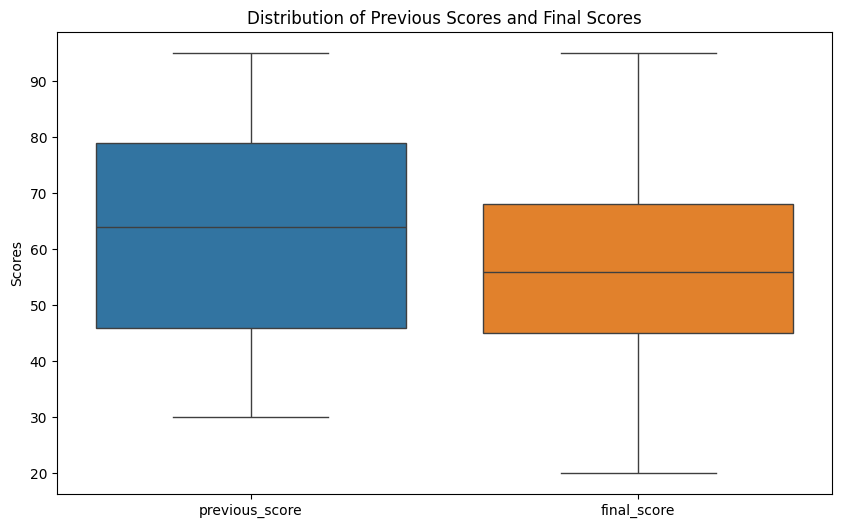

In [6]:
# create box plot to compare the distribution of previous scores and final scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=student_performance_df[['previous_score', 'final_score']])
plt.title('Distribution of Previous Scores and Final Scores')
plt.ylabel('Scores')
plt.show()

##### The plot above shows:
1. Most students passed at the first exam compared to the last exam.
2. In the previous_score the average score is between 60 to 70.
3. In the final_score  the average score is between 50 to 60.
4. In the previous_score the highest score is above 90 and lowest score is 30
5. In the final_score the highest score is above 90 and the lowest score is 20

### Create a heat map
- To spot pattern in the previous score and final score 
- To spot pattern with study hours and previous score and final score

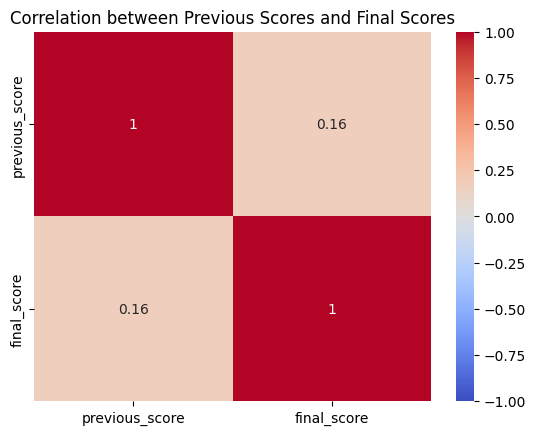

In [8]:
# creat heat map to show the correlation between previous scores and final scores
correlation_matrix = student_performance_df[['previous_score', 'final_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Previous Scores and Final Scores')
plt.show()

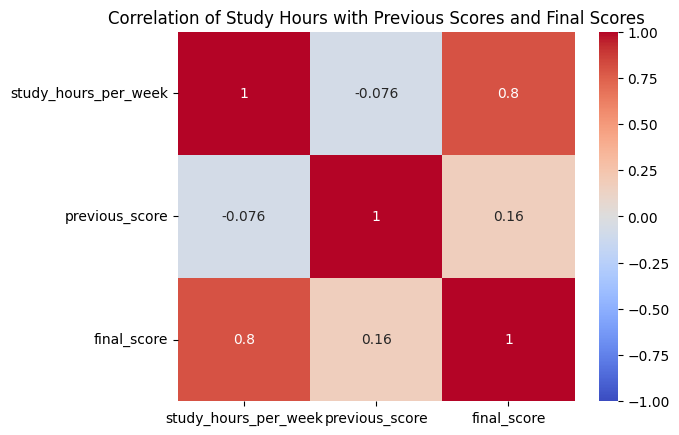

In [51]:
# create heat map to show correlation of study hours with previous scores and final scores
correlation_matrix_study_hours_with_scores = student_performance_df[['study_hours_per_week', 'previous_score', 'final_score']].corr()
sns.heatmap(correlation_matrix_study_hours_with_scores, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Study Hours with Previous Scores and Final Scores')
plt.show()

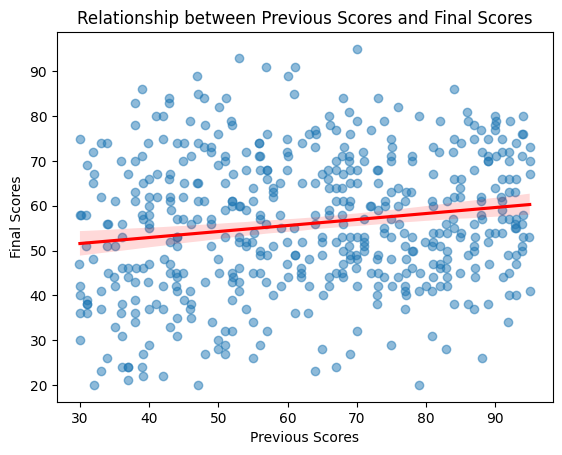

In [9]:
# plot a regression plot to show the relationship between previous scores and final scores
sns.regplot(x='previous_score',
            y='final_score',  #set the x and y axis to previous scores and final scores
            data=student_performance_df, #load data from the dataframe 
            scatter_kws={'alpha':0.5}, #set the transparency of the scatter points
            x_jitter=0.1, #add some jitter to the x-axis to prevent overlapping points
            #order=2, #fit a second-order polynomial regression line to capture any non-linear relationship
            line_kws={'color':'red'}) #set the color of the regression line to red 
plt.title('Relationship between Previous Scores and Final Scores')
plt.xlabel('Previous Scores')
plt.ylabel('Final Scores')
plt.show()

#### Create a new column in the csv files (average score)

In [10]:
# create a column in the frame to get the average score of previous scores and final scores
student_performance_df['average_score'] =  average(student_performance_df['previous_score'], student_performance_df['final_score'])
student_performance_df.head(5)

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed,average_score
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes,54.0
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No,55.5
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No,61.0
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes,72.5
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes,72.0


In [ ]:
student_performance_df

- visualization to show trends of average scores with study hours per week
- calculate R  and R2

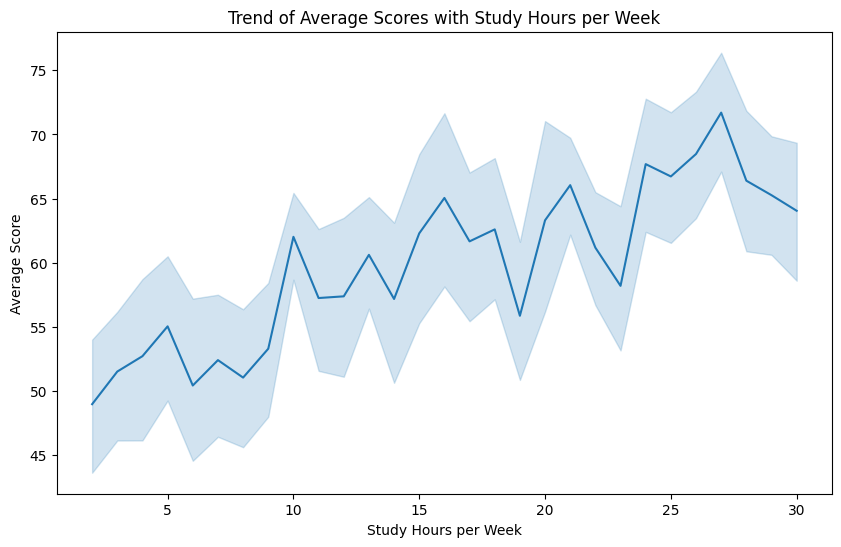

In [11]:
# plot a  line gragh to show the trend of average scores with study hours per week
plt.figure(figsize=(10, 6))
sns.lineplot(x='study_hours_per_week', y='average_score', data=student_performance_df)
plt.title('Trend of Average Scores with Study Hours per Week')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Score')
plt.show()

In [12]:
# calculate r and r^2 values for the relationship between study hours per week and average scores
X = student_performance_df['study_hours_per_week'].values.reshape(-1, 1)  # Reshape for sklearn
y = student_performance_df['average_score'].values  

model = LinearRegression()
model.fit(X, y)
r_squared = model.score(X, y)
r = np.sqrt(r_squared)
print(f"R-squared: {r_squared:.4f}")
print(f"R: {r:.4f}")



R-squared: 0.1725
R: 0.4153


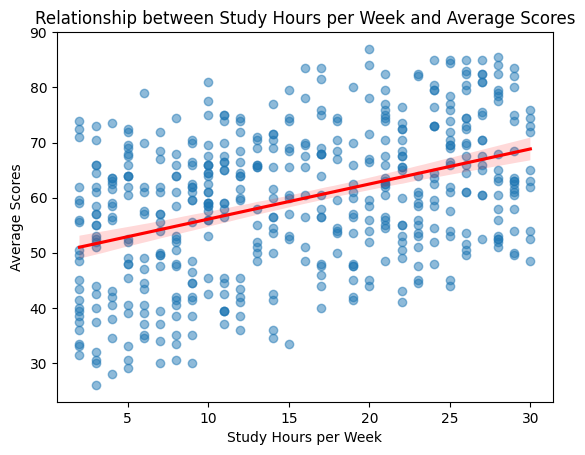

In [14]:
# plot the graph of study hours per week vs average scores with the regression line
sns.regplot(x='study_hours_per_week', y='average_score', data=student_performance_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Study Hours per Week and Average Scores')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Scores')
plt.show()

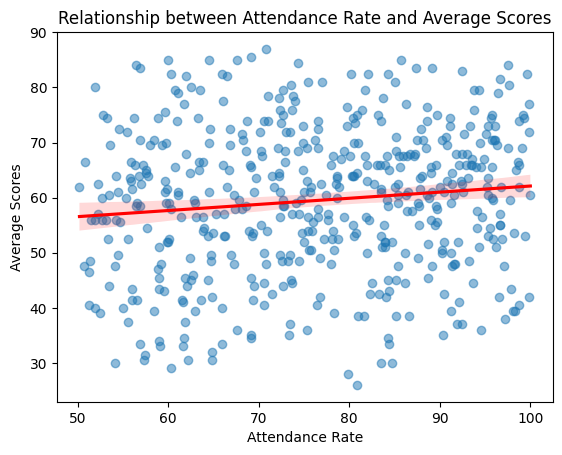

In [15]:
# plot a regression plot to show the relationship between attendance rate and average scores
sns.regplot(x='attendance_rate', y='average_score', data=student_performance_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Attendance Rate and Average Scores')
plt.xlabel('Attendance Rate')
plt.ylabel('Average Scores')
plt.show()